# Import Necessary Libraries


In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Import DataSet

In [2]:
df=pd.read_csv('../input/house-prices-advanced-regression-techniques/train.csv')

# OverView

In [3]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.corr()['SalePrice'].sort_values()

KitchenAbvGr    -0.135907
EnclosedPorch   -0.128578
MSSubClass      -0.084284
OverallCond     -0.077856
YrSold          -0.028923
LowQualFinSF    -0.025606
Id              -0.021917
MiscVal         -0.021190
BsmtHalfBath    -0.016844
BsmtFinSF2      -0.011378
3SsnPorch        0.044584
MoSold           0.046432
PoolArea         0.092404
ScreenPorch      0.111447
BedroomAbvGr     0.168213
BsmtUnfSF        0.214479
BsmtFullBath     0.227122
LotArea          0.263843
HalfBath         0.284108
OpenPorchSF      0.315856
2ndFlrSF         0.319334
WoodDeckSF       0.324413
LotFrontage      0.351799
BsmtFinSF1       0.386420
Fireplaces       0.466929
MasVnrArea       0.477493
GarageYrBlt      0.486362
YearRemodAdd     0.507101
YearBuilt        0.522897
TotRmsAbvGrd     0.533723
FullBath         0.560664
1stFlrSF         0.605852
TotalBsmtSF      0.613581
GarageArea       0.623431
GarageCars       0.640409
GrLivArea        0.708624
OverallQual      0.790982
SalePrice        1.000000
Name: SalePr

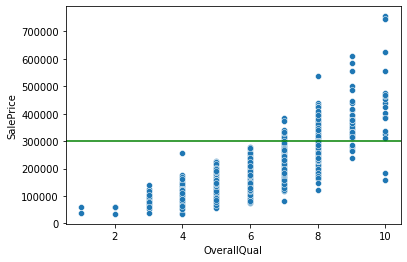

In [5]:
sns.scatterplot(data=df,x='OverallQual',y='SalePrice')
plt.axhline(y=300000 , color='g')

# Scatterplot for GrLivArea & SalePrice

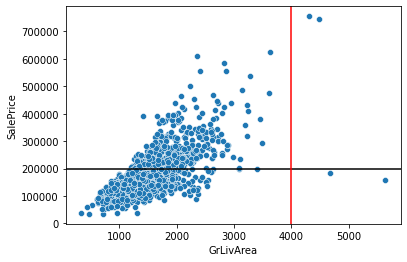

In [6]:
sns.scatterplot(data=df , x='GrLivArea',y='SalePrice')
plt.axhline(y=200000, color='black')
plt.axvline(x=4000, color='red')

In [7]:
df[(df['GrLivArea']>4000)&(df['SalePrice']<200000)][['SalePrice','GrLivArea']]

,SalePrice,GrLivArea
523,184750,4676
1298,160000,5642


# Drop Outliers

In [8]:
index_drop=df[(df['GrLivArea']>4000)&(df['SalePrice']<200000)].index

In [9]:
index_drop

Int64Index([523, 1298], dtype='int64')

In [10]:
df=df.drop(index_drop,axis=0)

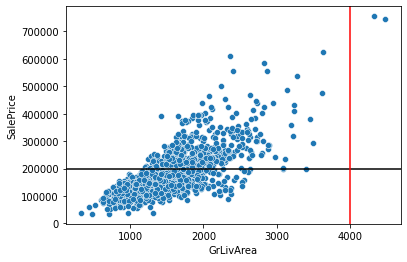

In [11]:
sns.scatterplot(data=df , x='GrLivArea',y='SalePrice')
plt.axhline(y=200000, color='black')
plt.axvline(x=4000, color='red')

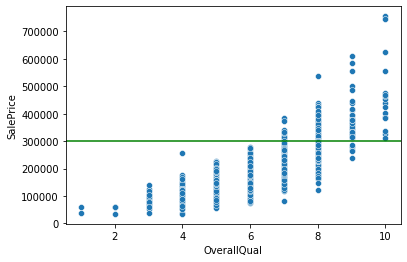

In [12]:
sns.scatterplot(data=df,x='OverallQual',y='SalePrice')
plt.axhline(y=300000 , color='g')

<AxesSubplot:xlabel='OverallQual', ylabel='SalePrice'>

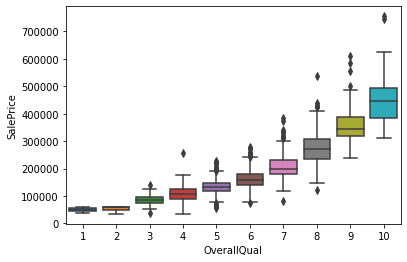

In [13]:
sns.boxplot(data=df,x='OverallQual',y='SalePrice')

In [14]:
with open('../input/house-prices-advanced-regression-techniques/data_description.txt','r') as f:
    print(f.read())

MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES

MSZoning: Identifies the general zoning classification of the sale.
		
       A	Agriculture
       C	Commercial
       FV	Floating Village Residential
       I	Industrial
       RH	Residential High Density
       RL	Residential Low Density
       RP	Residential Low Density Park 
       RM

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1458 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1458 non-null   int64  
 1   MSSubClass     1458 non-null   int64  
 2   MSZoning       1458 non-null   object 
 3   LotFrontage    1199 non-null   float64
 4   LotArea        1458 non-null   int64  
 5   Street         1458 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1458 non-null   object 
 8   LandContour    1458 non-null   object 
 9   Utilities      1458 non-null   object 
 10  LotConfig      1458 non-null   object 
 11  LandSlope      1458 non-null   object 
 12  Neighborhood   1458 non-null   object 
 13  Condition1     1458 non-null   object 
 14  Condition2     1458 non-null   object 
 15  BldgType       1458 non-null   object 
 16  HouseStyle     1458 non-null   object 
 17  OverallQual    1458 non-null   int64  
 18  OverallC

In [16]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [17]:
df=df.drop('Id',axis=1)

# Find Missing Data

In [18]:
((df.isnull().sum())/len(df))*100

MSSubClass        0.00000
MSZoning          0.00000
LotFrontage      17.76406
LotArea           0.00000
Street            0.00000
                   ...   
MoSold            0.00000
YrSold            0.00000
SaleType          0.00000
SaleCondition     0.00000
SalePrice         0.00000
Length: 80, dtype: float64

In [19]:
def missing_percent(df):
    nan_percent=((df.isnull().sum())/len(df))*100
    nan_percent=nan_percent[nan_percent>0].sort_values()
    return nan_percent

In [20]:
nan_percent=missing_percent(df)

In [21]:
nan_percent

Electrical       0.068587
MasVnrType       0.548697
MasVnrArea       0.548697
BsmtQual         2.537723
BsmtCond         2.537723
BsmtFinType1     2.537723
BsmtExposure     2.606310
BsmtFinType2     2.606310
GarageCond       5.555556
GarageQual       5.555556
GarageFinish     5.555556
GarageType       5.555556
GarageYrBlt      5.555556
LotFrontage     17.764060
FireplaceQu     47.325103
Fence           80.727023
Alley           93.758573
MiscFeature     96.296296
PoolQC          99.588477
dtype: float64

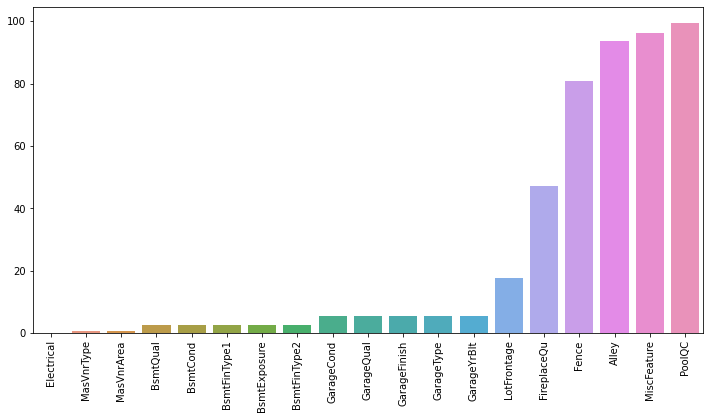

In [22]:
plt.figure(figsize=(12,6))
sns.barplot(x=nan_percent.index , y=nan_percent)
plt.xticks(rotation=90);

In [23]:
df[df['Electrical'].isnull()]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1379,80,RL,73.0,9735,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,167500


In [24]:
df[df['MasVnrType'].isnull()]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
234,60,RL,NaN,7851,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,216500
529,20,RL,NaN,32668,Pave,NaN,IR1,Lvl,AllPub,CulDSac,...,0,NaN,NaN,NaN,0,3,2007,WD,Alloca,200624
650,60,FV,65.0,8125,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,205950
936,20,RL,67.0,10083,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2009,WD,Normal,184900
973,20,FV,95.0,11639,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,12,2008,New,Partial,182000
977,120,FV,35.0,4274,Pave,Pave,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,11,2007,New,Partial,199900
1243,20,RL,107.0,13891,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2006,New,Partial,465000
1278,60,RL,75.0,9473,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,3,2008,WD,Normal,237000


In [25]:
df=df.dropna(subset=['Electrical' , 'MasVnrType'],axis=0)

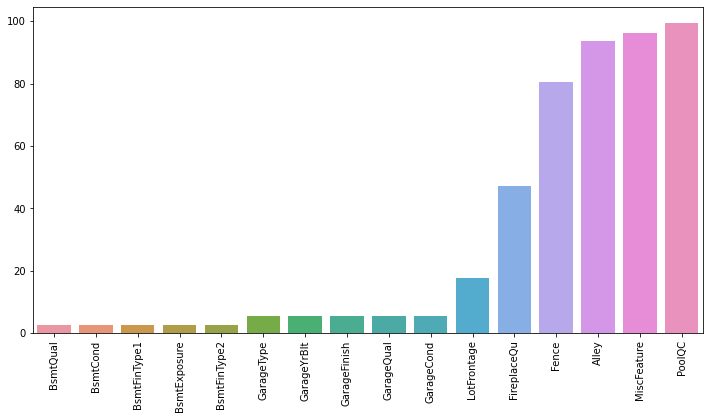

In [26]:
nan_percent=missing_percent(df)
plt.figure(figsize=(12,6))
sns.barplot(x=nan_percent.index , y=nan_percent)
plt.xticks(rotation=90);

In [27]:
df[df['BsmtFinType1'].isnull()]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
17,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
39,90,RL,65.0,6040,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,6,2008,WD,AdjLand,82000
90,20,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,7,2006,WD,Normal,109900
102,90,RL,64.0,7018,Pave,NaN,Reg,Bnk,AllPub,Inside,...,0,NaN,NaN,NaN,0,6,2009,WD,Alloca,118964
156,20,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,6,2006,WD,Normal,109500
182,20,RL,60.0,9060,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal,120000
259,20,RM,70.0,12702,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,97000
342,90,RL,NaN,8544,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,5,2006,WD,Normal,87500
362,85,RL,64.0,7301,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,7,2009,ConLD,Normal,198500
371,50,RL,80.0,17120,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,134432


In [28]:
df[df['BsmtQual'].isnull()]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
17,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
39,90,RL,65.0,6040,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,6,2008,WD,AdjLand,82000
90,20,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,7,2006,WD,Normal,109900
102,90,RL,64.0,7018,Pave,NaN,Reg,Bnk,AllPub,Inside,...,0,NaN,NaN,NaN,0,6,2009,WD,Alloca,118964
156,20,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,6,2006,WD,Normal,109500
182,20,RL,60.0,9060,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal,120000
259,20,RM,70.0,12702,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,97000
342,90,RL,NaN,8544,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,5,2006,WD,Normal,87500
362,85,RL,64.0,7301,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,7,2009,ConLD,Normal,198500
371,50,RL,80.0,17120,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,134432


In [29]:
df[df['BsmtCond'].isnull()]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
17,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
39,90,RL,65.0,6040,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,6,2008,WD,AdjLand,82000
90,20,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,7,2006,WD,Normal,109900
102,90,RL,64.0,7018,Pave,NaN,Reg,Bnk,AllPub,Inside,...,0,NaN,NaN,NaN,0,6,2009,WD,Alloca,118964
156,20,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,6,2006,WD,Normal,109500
182,20,RL,60.0,9060,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal,120000
259,20,RM,70.0,12702,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,97000
342,90,RL,NaN,8544,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,5,2006,WD,Normal,87500
362,85,RL,64.0,7301,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,7,2009,ConLD,Normal,198500
371,50,RL,80.0,17120,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,134432


In [30]:
bsmt_num_cols=['BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF']
df[bsmt_num_cols]=df[bsmt_num_cols].fillna(0)

In [31]:
bsmt_str_cols=['BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2']
df[bsmt_str_cols]=df[bsmt_str_cols].fillna('None')

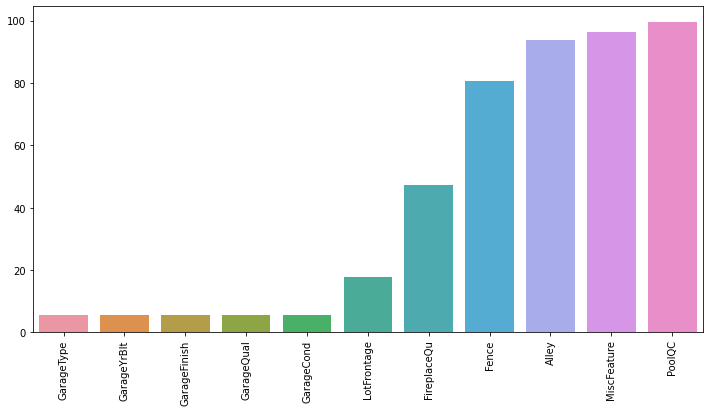

In [32]:
nan_percent=missing_percent(df)
plt.figure(figsize=(12,6))
sns.barplot(x=nan_percent.index , y=nan_percent)
plt.xticks(rotation=90);

In [33]:
df['GarageYrBlt']=df['GarageYrBlt'].fillna(0)

In [34]:
grg_str_cols=['GarageType','GarageFinish','GarageQual','GarageCond']
df[grg_str_cols]=df[grg_str_cols].fillna('None')

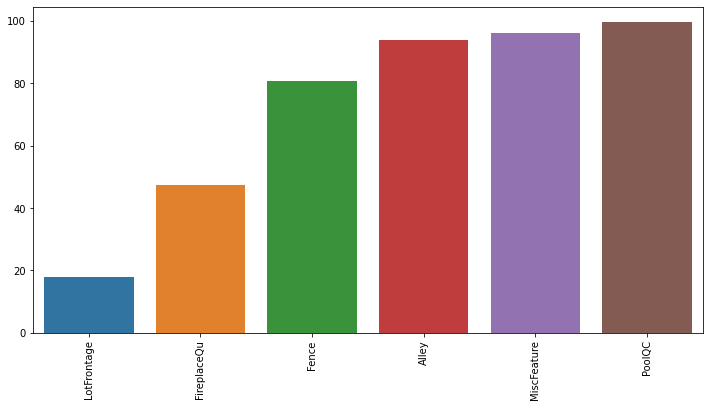

In [35]:
nan_percent=missing_percent(df)
plt.figure(figsize=(12,6))
sns.barplot(x=nan_percent.index , y=nan_percent)
plt.xticks(rotation=90);

In [36]:
df=df.drop(['Fence','Alley','MiscFeature','PoolQC'], axis=1)

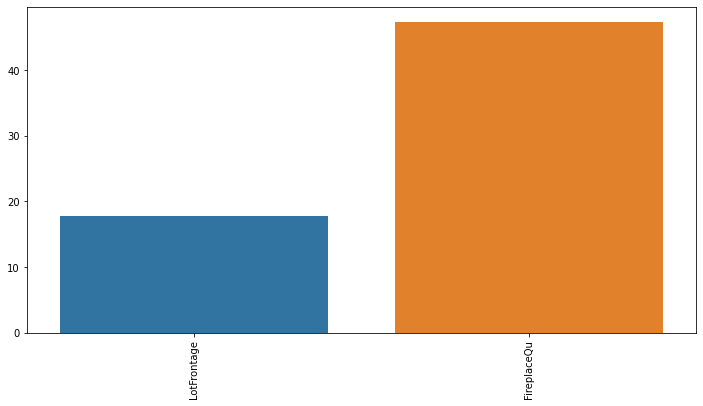

In [37]:
nan_percent=missing_percent(df)
plt.figure(figsize=(12,6))
sns.barplot(x=nan_percent.index , y=nan_percent)
plt.xticks(rotation=90);

In [38]:
df['FireplaceQu']=df['FireplaceQu'].fillna('None')

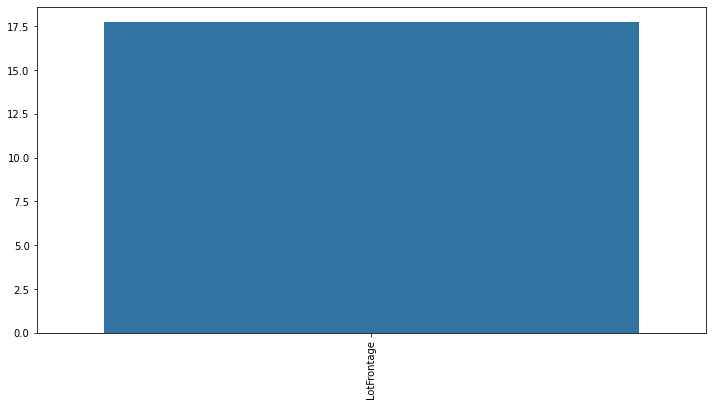

In [39]:
nan_percent=missing_percent(df)
plt.figure(figsize=(12,6))
sns.barplot(x=nan_percent.index , y=nan_percent)
plt.xticks(rotation=90);

<AxesSubplot:xlabel='LotFrontage', ylabel='Neighborhood'>

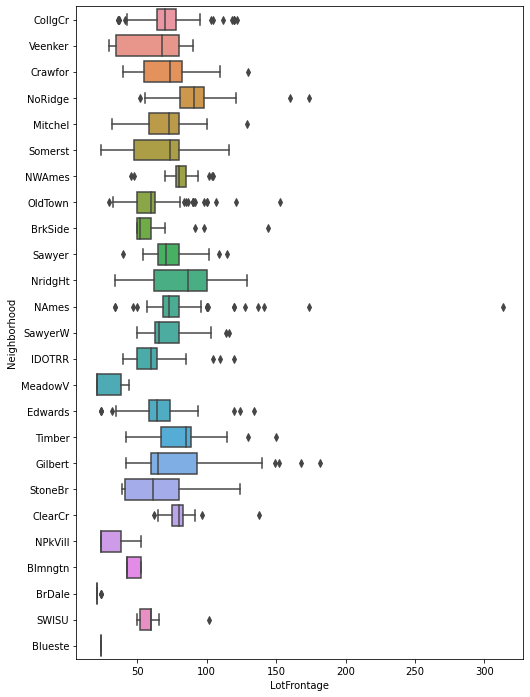

In [40]:
plt.figure(figsize=(8,12))
sns.boxplot(data=df , x='LotFrontage', y='Neighborhood')

In [41]:
df.groupby('Neighborhood')['LotFrontage'].mean()

Neighborhood
Blmngtn    47.142857
Blueste    24.000000
BrDale     21.562500
BrkSide    57.509804
ClearCr    83.461538
CollgCr    71.656000
Crawfor    71.804878
Edwards    64.811111
Gilbert    79.877551
IDOTRR     62.500000
MeadowV    27.800000
Mitchel    70.083333
NAmes      76.462366
NPkVill    32.285714
NWAmes     81.288889
NoRidge    91.878788
NridgHt    81.546667
OldTown    62.788991
SWISU      58.913043
Sawyer     74.437500
SawyerW    71.591837
Somerst    64.653333
StoneBr    62.700000
Timber     80.379310
Veenker    59.714286
Name: LotFrontage, dtype: float64

In [42]:
df.groupby('Neighborhood')['LotFrontage'].transform(lambda val: val.fillna(val.mean()))

0       65.0
1       80.0
2       68.0
3       60.0
4       84.0
        ... 
1455    62.0
1456    85.0
1457    66.0
1458    68.0
1459    75.0
Name: LotFrontage, Length: 1449, dtype: float64

(array([0]), [Text(0, 0, 'LotFrontage')])

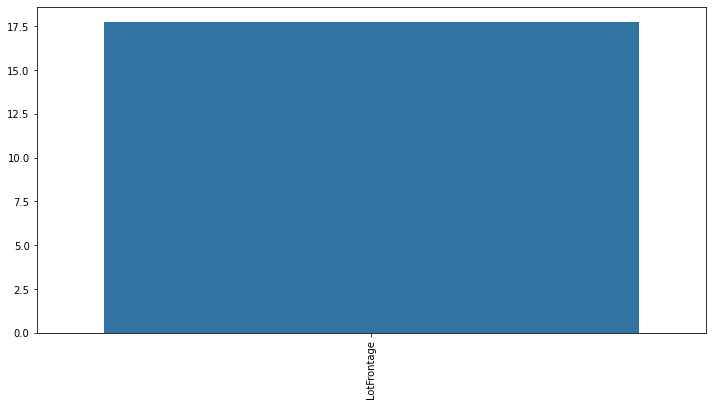

In [43]:
nan_percent=missing_percent(df)
plt.figure(figsize=(12,6))
sns.barplot(x=nan_percent.index , y=nan_percent)
plt.xticks(rotation=90)

In [44]:
df['LotFrontage']=df['LotFrontage'].fillna(0)

In [45]:
nan_percent=missing_percent(df)

In [46]:
nan_percent

Series([], dtype: float64)

# Numerical Columns to Categorical

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1449 entries, 0 to 1459
Data columns (total 76 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1449 non-null   int64  
 1   MSZoning       1449 non-null   object 
 2   LotFrontage    1449 non-null   float64
 3   LotArea        1449 non-null   int64  
 4   Street         1449 non-null   object 
 5   LotShape       1449 non-null   object 
 6   LandContour    1449 non-null   object 
 7   Utilities      1449 non-null   object 
 8   LotConfig      1449 non-null   object 
 9   LandSlope      1449 non-null   object 
 10  Neighborhood   1449 non-null   object 
 11  Condition1     1449 non-null   object 
 12  Condition2     1449 non-null   object 
 13  BldgType       1449 non-null   object 
 14  HouseStyle     1449 non-null   object 
 15  OverallQual    1449 non-null   int64  
 16  OverallCond    1449 non-null   int64  
 17  YearBuilt      1449 non-null   int64  
 18  YearRemo

In [48]:
df['MSSubClass']

0       60
1       20
2       60
3       70
4       60
        ..
1455    60
1456    20
1457    70
1458    20
1459    20
Name: MSSubClass, Length: 1449, dtype: int64

In [49]:
#Convert to String:
df['MSSubClass']= df['MSSubClass'].apply(str)

In [50]:
df.info()
#or: df['MS SubClass'].dtype

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1449 entries, 0 to 1459
Data columns (total 76 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1449 non-null   object 
 1   MSZoning       1449 non-null   object 
 2   LotFrontage    1449 non-null   float64
 3   LotArea        1449 non-null   int64  
 4   Street         1449 non-null   object 
 5   LotShape       1449 non-null   object 
 6   LandContour    1449 non-null   object 
 7   Utilities      1449 non-null   object 
 8   LotConfig      1449 non-null   object 
 9   LandSlope      1449 non-null   object 
 10  Neighborhood   1449 non-null   object 
 11  Condition1     1449 non-null   object 
 12  Condition2     1449 non-null   object 
 13  BldgType       1449 non-null   object 
 14  HouseStyle     1449 non-null   object 
 15  OverallQual    1449 non-null   int64  
 16  OverallCond    1449 non-null   int64  
 17  YearBuilt      1449 non-null   int64  
 18  YearRemo

# Creating Dummy Variables

In [51]:
df.select_dtypes(include='object')

,MSSubClass,MSZoning,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,SaleType,SaleCondition
0,60,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Gd,Typ,None,Attchd,RFn,TA,TA,Y,WD,Normal
1,20,RL,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,TA,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
2,60,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
3,70,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,...,Gd,Typ,Gd,Detchd,Unf,TA,TA,Y,WD,Abnorml
4,60,RL,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,...,TA,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
1456,20,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,...,TA,Min1,TA,Attchd,Unf,TA,TA,Y,WD,Normal
1457,70,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,...,Gd,Typ,Gd,Attchd,RFn,TA,TA,Y,WD,Normal
1458,20,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Gd,Typ,None,Attchd,Unf,TA,TA,Y,WD,Normal


# Number & Object Sepratation

In [52]:
df_num=df.select_dtypes(exclude='object')
df_obj=df.select_dtypes(include='object')
df_num.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1449 entries, 0 to 1459
Data columns (total 36 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   LotFrontage    1449 non-null   float64
 1   LotArea        1449 non-null   int64  
 2   OverallQual    1449 non-null   int64  
 3   OverallCond    1449 non-null   int64  
 4   YearBuilt      1449 non-null   int64  
 5   YearRemodAdd   1449 non-null   int64  
 6   MasVnrArea     1449 non-null   float64
 7   BsmtFinSF1     1449 non-null   int64  
 8   BsmtFinSF2     1449 non-null   int64  
 9   BsmtUnfSF      1449 non-null   int64  
 10  TotalBsmtSF    1449 non-null   int64  
 11  1stFlrSF       1449 non-null   int64  
 12  2ndFlrSF       1449 non-null   int64  
 13  LowQualFinSF   1449 non-null   int64  
 14  GrLivArea      1449 non-null   int64  
 15  BsmtFullBath   1449 non-null   int64  
 16  BsmtHalfBath   1449 non-null   int64  
 17  FullBath       1449 non-null   int64  
 18  HalfBath

In [53]:
df_obj.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1449 entries, 0 to 1459
Data columns (total 40 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   MSSubClass     1449 non-null   object
 1   MSZoning       1449 non-null   object
 2   Street         1449 non-null   object
 3   LotShape       1449 non-null   object
 4   LandContour    1449 non-null   object
 5   Utilities      1449 non-null   object
 6   LotConfig      1449 non-null   object
 7   LandSlope      1449 non-null   object
 8   Neighborhood   1449 non-null   object
 9   Condition1     1449 non-null   object
 10  Condition2     1449 non-null   object
 11  BldgType       1449 non-null   object
 12  HouseStyle     1449 non-null   object
 13  RoofStyle      1449 non-null   object
 14  RoofMatl       1449 non-null   object
 15  Exterior1st    1449 non-null   object
 16  Exterior2nd    1449 non-null   object
 17  MasVnrType     1449 non-null   object
 18  ExterQual      1449 non-null

In [54]:
df_obj=pd.get_dummies(df_obj,drop_first=True)

In [55]:
df_obj.shape

(1449, 223)

In [56]:
df_num.shape

(1449, 36)

In [57]:
Final_df=pd.concat([df_num,df_obj],axis=1)
Final_df.shape

(1449, 259)

In [58]:
Final_df.head()

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,65.0,8450,7,5,2003,2003,196.0,706,0,150,...,0,0,0,0,1,0,0,0,1,0
1,80.0,9600,6,8,1976,1976,0.0,978,0,284,...,0,0,0,0,1,0,0,0,1,0
2,68.0,11250,7,5,2001,2002,162.0,486,0,434,...,0,0,0,0,1,0,0,0,1,0
3,60.0,9550,7,5,1915,1970,0.0,216,0,540,...,0,0,0,0,1,0,0,0,0,0
4,84.0,14260,8,5,2000,2000,350.0,655,0,490,...,0,0,0,0,1,0,0,0,1,0


# Linear Regression

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn import metrics
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNetCV

In [60]:
x = Final_df.drop('SalePrice', axis = 1)
y = Final_df['SalePrice'] 
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=101)
model= LinearRegression()
model.fit(X_train, y_train)
y_pred=model.predict(X_test)

In [61]:
MAE=metrics.mean_absolute_error(y_test,y_pred)
MSE=metrics.mean_squared_error(y_test,y_pred)
RMSE=np.sqrt(MSE)

In [62]:
pd.DataFrame(data=[MAE,MSE,RMSE],index=["MAE","MSE","RMSE"],columns=["LinearRegression"])


,LinearRegression
MAE,1.770492e+04
MSE,7.683064e+08
RMSE,2.771834e+04


# Regularization

In [63]:
#Ridge Regression
ridge_model=Ridge(alpha=10)

In [64]:
ridge_model.fit(X_train,y_train)

Ridge(alpha=10)

In [65]:
y_pred=ridge_model.predict(X_test)

In [66]:
MAE_new=metrics.mean_absolute_error(y_test,y_pred)
MSE_new=metrics.mean_squared_error(y_test,y_pred)
RMSE_new=np.sqrt(MSE_new)

In [67]:
data={'LinearRegression':[MAE,MSE,RMSE],"Ridge regression":[MAE_new,MSE_new,RMSE_new]}
pd.DataFrame(data,index=["MAE","MSE","RMSE"])

,LinearRegression,Ridge regression
MAE,1.770492e+04,1.673126e+04
MSE,7.683064e+08,7.245709e+08
RMSE,2.771834e+04,2.691785e+04


In [68]:
ridge_cv_model=RidgeCV(alphas=(0.1, 4.0, 10.0),scoring="neg_mean_absolute_error")

In [69]:
ridge_cv_model.fit(X_train,y_train)

RidgeCV(alphas=array([ 0.1,  4. , 10. ]), scoring='neg_mean_absolute_error')

In [70]:
ridge_cv_model.alpha_

10.0

In [71]:
y_pred_ridge=ridge_cv_model.predict(X_test)

In [72]:
MAE_n1=metrics.mean_absolute_error(y_test,y_pred_ridge)
MSE_n1=metrics.mean_squared_error(y_test,y_pred_ridge)
RMSE_n1=np.sqrt(MSE_n1)

In [73]:
data={'LinearRegression':[MAE,MSE,RMSE],"Ridge regression":[MAE_new,MSE_new,RMSE_new],"Ridgecv":[MAE_n1,MSE_n1,RMSE_n1]}
pd.DataFrame(data,index=["MAE","MSE","RMSE"])

,LinearRegression,Ridge regression,Ridgecv
MAE,1.770492e+04,1.673126e+04,1.673126e+04
MSE,7.683064e+08,7.245709e+08,7.245714e+08
RMSE,2.771834e+04,2.691785e+04,2.691786e+04


In [74]:
 #Lasso regression
lasso_cv_model=LassoCV(eps=0.1,n_alphas=100,cv=5) 
lasso_cv_model.fit(X_train,y_train)

LassoCV(cv=5, eps=0.1)

In [75]:
lasso_cv_model.alpha_

21737737.009130463

In [76]:
y_pred_lasso=lasso_cv_model.predict(X_test)

In [77]:
MAE_n2=metrics.mean_absolute_error(y_test,y_pred_lasso)
MSE_n2=metrics.mean_squared_error(y_test,y_pred_lasso)
RMSE_n2=np.sqrt(MSE_n2)
data={'LinearRegression':[MAE,MSE,RMSE],"Ridge regression":[MAE_new,MSE_new,RMSE_new],"Ridgecv":[MAE_n1,MSE_n1,RMSE_n1],"Lassocv":[MAE_n2,MSE_n2,RMSE_n2]}
pd.DataFrame(data,index=["MAE","MSE","RMSE"])

,LinearRegression,Ridge regression,Ridgecv,Lassocv
MAE,1.770492e+04,1.673126e+04,1.673126e+04,5.086610e+04
MSE,7.683064e+08,7.245709e+08,7.245714e+08,5.332566e+09
RMSE,2.771834e+04,2.691785e+04,2.691786e+04,7.302442e+04


In [78]:
#Elastic Net
elastic_model=ElasticNetCV(l1_ratio=[0.1,0.5,0.7,0.9,0.95,0.99,1],cv=5,max_iter=100000)

In [79]:
elastic_model.fit(X_train,y_train)
elastic_model.l1_ratio_

1.0

In [80]:
y_pred_elastic=elastic_model.predict(X_test)

In [81]:
MAE_n3=metrics.mean_absolute_error(y_test,y_pred_elastic)
MSE_n3=metrics.mean_squared_error(y_test,y_pred_elastic)
RMSE_n3=np.sqrt(MSE_n3)

In [82]:
data={'LinearRegression':[MAE,MSE,RMSE],"Ridge regression":[MAE_new,MSE_new,RMSE_new],"Ridgecv":[MAE_n1,MSE_n1,RMSE_n1],"Lassocv":[MAE_n2,MSE_n2,RMSE_n2],"elasticnet":[MAE_n3,MSE_n3,RMSE_n3]}
pd.DataFrame(data,index=["MAE","MSE","RMSE"])

,LinearRegression,Ridge regression,Ridgecv,Lassocv,elasticnet
MAE,1.770492e+04,1.673126e+04,1.673126e+04,5.086610e+04,2.478042e+04
MSE,7.683064e+08,7.245709e+08,7.245714e+08,5.332566e+09,1.388500e+09
RMSE,2.771834e+04,2.691785e+04,2.691786e+04,7.302442e+04,3.726258e+04
